In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# -------------------------------------------------
# 1. Load dataset
# -------------------------------------------------
df = pd.read_excel(
    "/Users/Altair93/Documents/Dottorato/PATHS/Python_analisys/Intermediate_data/statistic/Database_PlanB.xlsx"
)

print("Dataset shape:", df.shape)

# -------------------------------------------------
# 2. Define EEG variables (same logic as Step 1)
# -------------------------------------------------
metrics = ["exponent", "offset", "lziv", "higuci", "theta", "delta"]

eeg_cols = [
    c for c in df.columns
    if any(m in c.lower() for m in metrics)
    and (
        "_avg" in c.lower()
        or "_hemi_l" in c.lower()
        or "_hemi_r" in c.lower()
        or "_hemi_asym" in c.lower()
    )
    and df[c].dtype != "object"
]

print(f"EEG vars ({len(eeg_cols)}):")
for c in eeg_cols:
    print(" -", c)

# -------------------------------------------------
# 3. Define cognitive variables
# -------------------------------------------------

cognitive_groups = {
    "Global / Reserve": [
        "mmse", "criq"
    ],
    "Attention / Short-term Memory": [
        "span_for", 
    ],
    "Verbal and Visual Memory": [
        "reyword", "reyfig",
    ],
    "Language / Semantic": [
        "trog", "semantic", "denomdescr"
    ],
    "Executive / Control": [
        "phonemic", "span_back"
    ],
}

# Appiattiamo la lista di tutte le colonne cognitive candidate
all_cog_candidates = [c for group in cognitive_groups.values() for c in group]

# Teniamo solo quelle effettivamente presenti nel dataset e numeriche
cog_cols_present = [
    c for c in all_cog_candidates
    if c in df.columns and df[c].dtype != "object"
]

print("\nCognitive vars found in dataframe:")
for c in cog_cols_present:
    print(" -", c)

# -------------------------------------------------
# 4. Helper: partial Spearman
# -------------------------------------------------

covariates_cog = []
for cand in ["age", "education", "time_onset_eeg"]:
    if cand in df.columns:
        covariates_cog.append(cand)

print("\nCovariates for partial EEG↔Cognition:", covariates_cog)

def partial_spearman(x, y, covars_df):
    tmp = pd.concat([x, y, covars_df], axis=1).dropna()
    if tmp.shape[0] < 5:
        return np.nan, np.nan, tmp.shape[0]
    X_cov = sm.add_constant(tmp[covars_df.columns])
    rx = sm.OLS(tmp[x.name], X_cov).fit().resid
    ry = sm.OLS(tmp[y.name], X_cov).fit().resid
    rho, pval = spearmanr(rx, ry)
    return rho, pval, tmp.shape[0]


Dataset shape: (31, 564)
EEG vars (24):
 - exponent_avg
 - offset_avg
 - lziv_avg
 - higuci_avg
 - theta_avg
 - delta_avg
 - exponent_HEMI_L
 - exponent_HEMI_R
 - exponent_HEMI_asym
 - offset_HEMI_L
 - offset_HEMI_R
 - offset_HEMI_asym
 - lziv_HEMI_L
 - lziv_HEMI_R
 - lziv_HEMI_asym
 - higuci_HEMI_L
 - higuci_HEMI_R
 - higuci_HEMI_asym
 - theta_HEMI_L
 - theta_HEMI_R
 - theta_HEMI_asym
 - delta_HEMI_L
 - delta_HEMI_R
 - delta_HEMI_asym

Cognitive vars found in dataframe:
 - mmse
 - criq
 - span_for
 - reyword
 - reyfig
 - trog
 - semantic
 - denomdescr
 - phonemic
 - span_back

Covariates for partial EEG↔Cognition: ['age', 'education', 'time_onset_eeg']


In [4]:
# -------------------------------------------------
# 5. Calcola correlazioni (simple e partial)
# -------------------------------------------------

rows_simple = []
rows_partial = []

for eeg_var in eeg_cols:
    for cog_var in cog_cols_present:

        # --- Simple Spearman
        d_simple = df[[eeg_var, cog_var]].dropna()
        if len(d_simple) >= 5:
            rho_s, p_s = spearmanr(d_simple[eeg_var], d_simple[cog_var])
            rows_simple.append({
                "EEG_feature": eeg_var,
                "Cognitive_var": cog_var,
                "Type": "Simple",
                "Spearman_rho": rho_s,
                "p_value": p_s,
                "N": len(d_simple)
            })

        # --- Partial Spearman (controllo Age/Education/Onset se disponibili)
        if len(covariates_cog) > 0:
            rho_p, p_p, n_p = partial_spearman(
                df[eeg_var],
                df[cog_var],
                df[covariates_cog]
            )
            rows_partial.append({
                "EEG_feature": eeg_var,
                "Cognitive_var": cog_var,
                "Type": "Partial",
                "Spearman_rho": rho_p,
                "p_value": p_p,
                "N": n_p
            })
        else:
            # se non abbiamo covariate da controllare, saltiamo la versione partial
            pass

df_simple = pd.DataFrame(rows_simple)
df_partial = pd.DataFrame(rows_partial)

# -------------------------------------------------
# 6. Correzione multipla FDR
#    Facciamo FDR per ciascuna variabile cognitiva separatamente.
#    (È quello che normalmente scrivi in Methods.)
# -------------------------------------------------

def apply_fdr_by_cognitive_var(df_in):
    df_out = df_in.copy()
    df_out["p_FDR"] = np.nan
    for cog in df_out["Cognitive_var"].unique():
        mask = df_out["Cognitive_var"] == cog
        pvals = df_out.loc[mask, "p_value"]
        if len(pvals) == 0:
            continue
        reject, p_corr, *_ = multipletests(pvals, method="fdr_bh")
        df_out.loc[mask, "p_FDR"] = p_corr
    return df_out

df_simple = apply_fdr_by_cognitive_var(df_simple)
df_partial = apply_fdr_by_cognitive_var(df_partial)

# Combina in un'unica tabella
cog_corr_all = pd.concat([df_simple, df_partial], axis=0)
cog_corr_all = cog_corr_all.sort_values(["Cognitive_var", "Type", "p_FDR"])



In [5]:
# Salva tutto
out_path_full = "/Users/Altair93/Documents/Dottorato/PATHS/Python_analisys/Intermediate_data/statistic/Step2a_Cognition_EEG_Correlations_All.xlsx"
cog_corr_all.to_excel(out_path_full, index=False)
print("\nSaved full cognition correlation table to:")
print(out_path_full)

# Tabella solo con effetti parziali significativi
sig_cog_partial = df_partial[
    (df_partial["p_FDR"].notna()) &
    (df_partial["p_FDR"] < 0.05)
].sort_values("p_FDR")

out_path_sig = "/Users/Altair93/Documents/Dottorato/PATHS/Python_analisys/Intermediate_data/statistic/Step2a_Cognition_EEG_Correlations_SignificantOnly.xlsx"
sig_cog_partial.to_excel(out_path_sig, index=False)

print("\nSignificant partial effects saved to:")
print(out_path_sig)
print("\nSignificant partial effects preview:")
print(sig_cog_partial[["EEG_feature", "Cognitive_var", "Spearman_rho", "p_FDR", "N"]])


Saved full cognition correlation table to:
/Users/Altair93/Documents/Dottorato/PATHS/Python_analisys/Intermediate_data/statistic/Step2a_Cognition_EEG_Correlations_All.xlsx

Significant partial effects saved to:
/Users/Altair93/Documents/Dottorato/PATHS/Python_analisys/Intermediate_data/statistic/Step2a_Cognition_EEG_Correlations_SignificantOnly.xlsx

Significant partial effects preview:
         EEG_feature Cognitive_var  Spearman_rho     p_FDR   N
194     theta_HEMI_R        reyfig     -0.661846  0.001632  30
44         theta_avg        reyfig     -0.591101  0.006991  30
104    offset_HEMI_R        reyfig     -0.555951  0.008541  30
184     theta_HEMI_L        reyfig     -0.562625  0.008541  30
24          lziv_avg        reyfig      0.522136  0.014785  30
14        offset_avg        reyfig     -0.508788  0.015802  30
124      lziv_HEMI_L        reyfig      0.503003  0.015802  30
94     offset_HEMI_L        reyfig     -0.448721  0.036306  30
134      lziv_HEMI_R        reyfig      0.

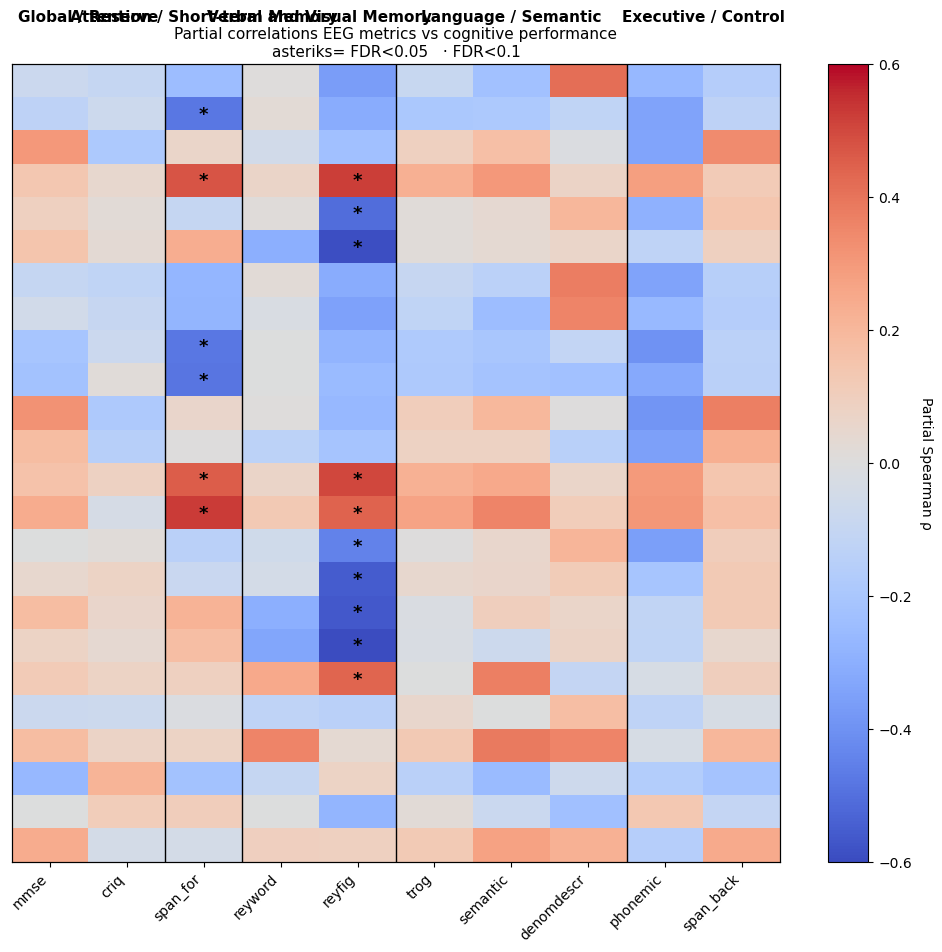

In [9]:
# -------------------------------------------------
# 7. Heatmap EEG ↔ Cognizione (Partial only)
# -------------------------------------------------

# Creiamo la matrice delle correlazioni
heat_cog = df_partial.pivot_table(
    index="EEG_feature",
    columns="Cognitive_var",
    values="Spearman_rho"
)

# Matrice parallela dei p_FDR
pvals_cog = df_partial.pivot_table(
    index="EEG_feature",
    columns="Cognitive_var",
    values="p_FDR"
)

# Ordiniamo le righe EEG come prima (global -> hemi -> asym)
def sort_key(name):
    n = str(name).lower()
    if "_avg" in n:
        return (0, n)
    elif "_hemi_l" in n or "_hemi_r" in n:
        return (1, n)
    elif "_hemi_asym" in n:
        return (2, n)
    else:
        return (3, n)

heat_cog = heat_cog.reindex(sorted(heat_cog.index, key=sort_key))
pvals_cog = pvals_cog.reindex(heat_cog.index)

# Ora costruiamo l'ordine delle colonne cognitive in blocchi
# in base ai gruppi cognitivi che abbiamo definito
ordered_cogs = []
block_centers = []
block_labels = []

start_idx = 0
for block_label, varlist in cognitive_groups.items():
    present_vars = [v for v in varlist if v in heat_cog.columns]
    if len(present_vars) == 0:
        continue
    ordered_cogs.extend(present_vars)
    # calcoliamo il centro del blocco per mettere l'etichetta sopra
    block_centers.append(start_idx + (len(present_vars)-1)/2)
    block_labels.append(block_label)
    start_idx += len(present_vars)

heat_cog = heat_cog[ordered_cogs]
pvals_cog = pvals_cog[ordered_cogs]

# separazioni visive tra blocchi cognitivi
split_positions = []
running = 0
for block_label, varlist in cognitive_groups.items():
    present_vars = [v for v in varlist if v in heat_cog.columns]
    if len(present_vars) == 0:
        continue
    running += len(present_vars)
    split_positions.append(running - 0.5)
# l'ultima split non ci serve perché è la fine del grafico → togliamo l'ultimo
if len(split_positions) > 0:
    split_positions = split_positions[:-1]

import numpy as np
import matplotlib.pyplot as plt

# ============
# Prep: coordinate a mano
# ============

n_rows = heat_cog.shape[0]   # numero di feature EEG
n_cols = heat_cog.shape[1]   # numero di test cognitivi

# Costruiamo una griglia (pcolormesh vuole i bordi delle celle)
x_edges = np.arange(n_cols + 1)
y_edges = np.arange(n_rows + 1)

Z = heat_cog.values  # matrice dei rho

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 0. Helper per abbreviare le label EEG
# -------------------------
def prettify_eeg_label(lbl: str) -> str:
    lbl = lbl.replace("_avg", " avg")
    lbl = lbl.replace("_HEMI_L", " hemi L")
    lbl = lbl.replace("_HEMI_R", " hemi R")
    lbl = lbl.replace("_HEMI_asym", " asym")
    lbl = lbl.replace("_hemi_l", " hemi L")
    lbl = lbl.replace("_hemi_r", " hemi R")
    lbl = lbl.replace("_hemi_asym", " asym")
    lbl = lbl.replace("_asym", " asym")
    return lbl

# -------------------------
# 1. Coordinate per pcolormesh
# -------------------------
n_rows = heat_cog.shape[0]   # EEG features
n_cols = heat_cog.shape[1]   # cognitive tests

x_edges = np.arange(n_cols + 1)
y_edges = np.arange(n_rows + 1)
Z = heat_cog.values

# -------------------------
# 2. Calcolo blocchi cognitivi per linee verticali e label sopra
# -------------------------
ordered_cogs = list(heat_cog.columns)

split_positions_new = []
block_centers = []
block_labels = []
running = 0
for block_label, varlist in cognitive_groups.items():
    present_vars = [v for v in varlist if v in ordered_cogs]
    if len(present_vars) == 0:
        continue
    start_col = running
    running += len(present_vars)
    end_col = running
    # centro del blocco per mettere il titolo ("Attention", "Memory", ecc.)
    center = (start_col + end_col) / 2
    block_centers.append(center)
    block_labels.append(block_label)
    split_positions_new.append(end_col)

# togliamo l'ultima posizione di split perché è la fine totale
if len(split_positions_new) > 0:
    split_positions_new = split_positions_new[:-1]

# -------------------------
# 3. Figure grande e leggibile
#    - width scala con n_cols (test cognitivi)
#    - height scala con n_rows (feature EEG)
# -------------------------
fig, ax = plt.subplots(
    figsize=(max(10, 0.7 * n_cols), max(8, 0.4 * n_rows))
)

cmap_plot = ax.pcolormesh(
    x_edges,
    y_edges,
    Z,
    cmap="coolwarm",
    vmin=-0.6,
    vmax=0.6,
    shading="auto"
)

cbar = plt.colorbar(cmap_plot, ax=ax)
cbar.ax.set_ylabel("Partial Spearman ρ", rotation=270, labelpad=15)

# -------------------------
# 4. Tick positions e label assi
# -------------------------
x_centers = np.arange(n_cols) + 0.5
y_centers = np.arange(n_rows) + 0.5

# X = test cognitivi
ax.set_xticks(x_centers)
ax.set_xticklabels(ordered_cogs, rotation=45, ha="right", fontsize=10)

# Y = feature EEG
ax.set_yticks(y_centers)
ax.set_yticklabels(
    [prettify_eeg_label(lbl) for lbl in heat_cog.index],
    fontsize=8
)

# limiti e orientamento
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.invert_yaxis()  # prima riga in alto

# -------------------------
# 5. Linee verticali per separare i domini cognitivi
# -------------------------
for xline in split_positions_new:
    ax.axvline(x=xline, color="black", linewidth=1.0)

# -------------------------
# 6. Asterischi/puntini per significatività FDR
# -------------------------
for i, eeg_feat in enumerate(heat_cog.index):
    for j, cog_var in enumerate(heat_cog.columns):
        p = pvals_cog.loc[eeg_feat, cog_var]
        if pd.notnull(p):
            if p < 0.05:
                mark = "*"
                size = 13
                weight = "bold"
            elif p < 0.1:
                mark = "·"
                size = 12
                weight = "normal"
            else:
                mark = None
            if mark is not None:
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    mark,
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=size,
                    fontweight=weight
                )

# -------------------------
# 7. Etichette dei blocchi cognitivi sopra
# -------------------------
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks([])
ax_top.set_yticks([])

for center, label in zip(block_centers, block_labels):
    ax_top.text(
        center,
        1.05,
        label,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        transform=ax_top.get_xaxis_transform()
    )

# -------------------------
# 8. Titolo e salvataggio
# -------------------------
ax.set_title(
    "Partial correlations EEG metrics vs cognitive performance\n"
    "asteriks= FDR<0.05   · FDR<0.1",
    fontsize=11
)

plt.tight_layout()

# versione ad alta risoluzione per tesi
plt.savefig(
    "/Users/Altair93/Documents/Dottorato/PATHS/Python_analisys/Results/Figures/Step2a_EEG_vs_Cognition_heatmap.png",
    dpi=300
)

plt.show()
